<a href="https://colab.research.google.com/github/muhammadtegarkurniawan/Tugas/blob/main/Tugas_tegarFix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [153]:
!pip install opencv-python
!pip install scikit-image

In [154]:
from google.colab import files
uploaded = files.upload()

Saving n9S000007837-2.avif to n9S000007837-2 (29).avif


Saving n9S000007837-2.avif to n9S000007837-2 (30).avif


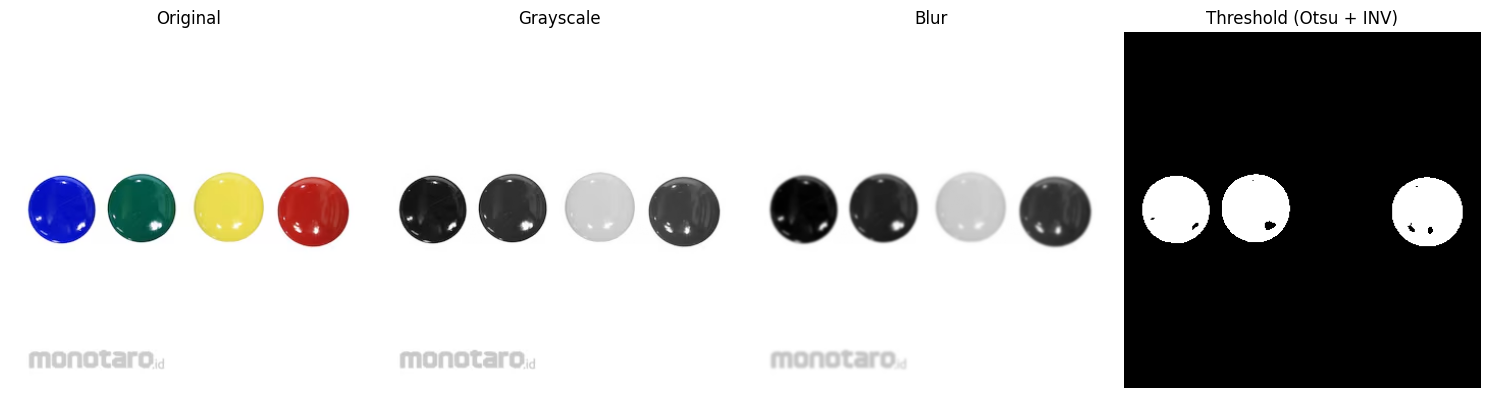

In [155]:
# =========================
# IMPORT LIBRARY
# =========================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# =========================
# UPLOAD GAMBAR
# =========================
uploaded = files.upload()

# Ambil nama file
image_path = list(uploaded.keys())[0]

# =========================
# LOAD GAMBAR
# =========================
image = cv2.imread(image_path)

# Validasi (biar gak error)
if image is None:
    raise ValueError("Gambar tidak terbaca!")

# Convert BGR ke RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert ke Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# =========================
# PREPROCESSING (PENTING)
# =========================
# Blur untuk mengurangi noise
blur = cv2.GaussianBlur(gray, (5,5), 0)

# =========================
# THRESHOLDING (OTSU + INV)
# =========================
ret, thresh = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# =========================
# VISUALISASI
# =========================
plt.figure(figsize=(15,5))

# Original
plt.subplot(1,4,1)
plt.title("Original")
plt.imshow(image_rgb)
plt.axis("off")

# Grayscale
plt.subplot(1,4,2)
plt.title("Grayscale")
plt.imshow(gray, cmap='gray')
plt.axis("off")

# Blur
plt.subplot(1,4,3)
plt.title("Blur")
plt.imshow(blur, cmap='gray')
plt.axis("off")

# Threshold
plt.subplot(1,4,4)
plt.title("Thresholding")
plt.imshow(thresh, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()

Saving n9S000007837-2.avif to n9S000007837-2 (31).avif


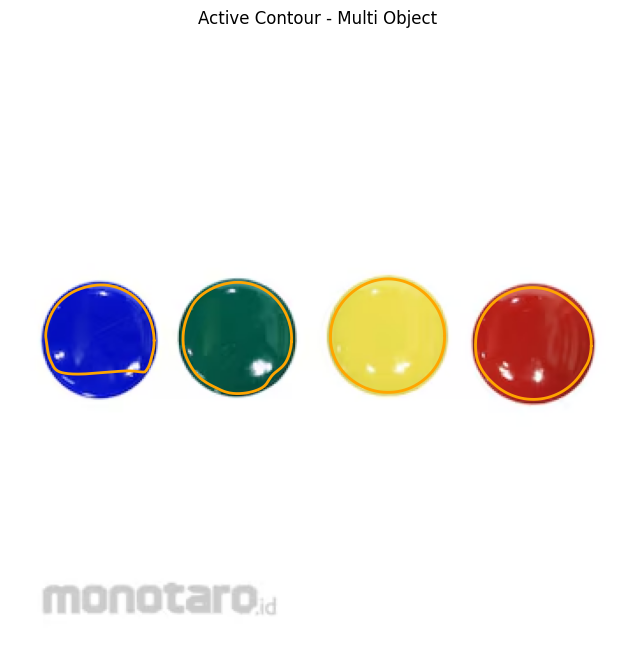

In [156]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from skimage.segmentation import active_contour
from skimage.filters import gaussian, sobel
from skimage.color import rgb2gray

# =========================
# 1. Upload gambar
# =========================
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# =========================
# 2. Baca gambar
# =========================
image = cv2.imread(filename)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# =========================
# 3. Grayscale + smoothing
# =========================
gray = rgb2gray(image)
gray = gaussian(gray, 2)

# =========================
# 4. Edge detection (untuk snake)
# =========================
edge = sobel(gray)

# =========================
# 5. Deteksi lingkaran (SEMUA warna)
# =========================
circles = cv2.HoughCircles(
    (gray * 255).astype(np.uint8),
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=80,
    param1=100,
    param2=20,
    minRadius=30,
    maxRadius=120
)

# =========================
# 6. Visualisasi
# =========================
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(image)

# =========================
# 7. Active Contour
# =========================
if circles is not None:
    circles = np.uint16(np.around(circles))

    for i in circles[0]:
        x, y, r = i

        # initial contour (sedikit di dalam objek)
        s = np.linspace(0, 2*np.pi, 300)
        init = np.array([
            y + (r-5)*np.sin(s),
            x + (r-5)*np.cos(s)
        ]).T

        snake = active_contour(
            edge,
            init,
            alpha=0.05,        # elastisitas
            beta=15,           # smooth (biar bulat)
            gamma=0.01,
            max_num_iter=2500,
            convergence=0.1
        )

        ax.plot(snake[:,1], snake[:,0], color='orange', lw=2)

# =========================
# 8. Output
# =========================
ax.set_title("Active Contour - Multi Object")
ax.axis('off')

plt.show()

Saving n9S000007837-2.avif to n9S000007837-2 (32).avif


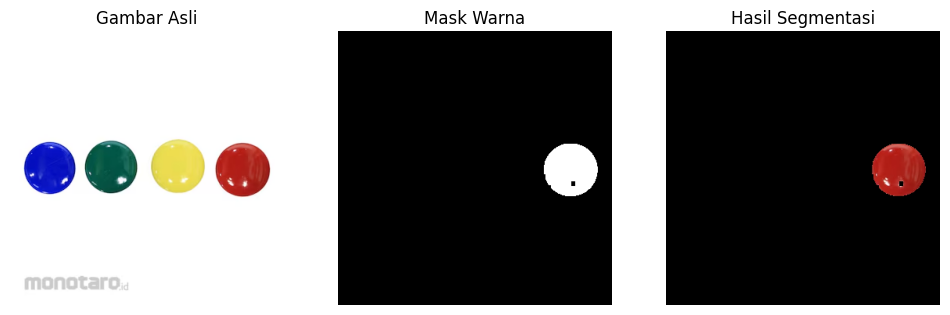

In [157]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload gambar
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Baca gambar
image = cv2.imread(filename)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert ke HSV
hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

# =========================
# RANGE WARNA MERAH
# =========================
lower_red1 = np.array([0,120,70])
upper_red1 = np.array([10,255,255])

lower_red2 = np.array([170,120,70])
upper_red2 = np.array([180,255,255])

mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)

mask = mask1 + mask2

# =========================
# MORPHOLOGY (BERSIHKAN NOISE)
# =========================
kernel = np.ones((5,5), np.uint8)

mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# =========================
# HASIL SEGMENTASI
# =========================
result = cv2.bitwise_and(image, image, mask=mask)

# =========================
# TAMPILKAN HASIL
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Gambar Asli")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Mask Warna")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Hasil Segmentasi")
plt.imshow(result)
plt.axis("off")

plt.show()

Saving n9S000007837-2.avif to n9S000007837-2 (33).avif


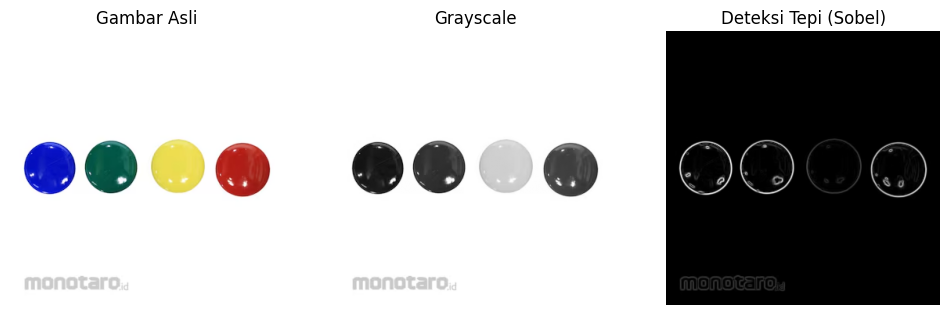

In [158]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload gambar
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Baca gambar
image = cv2.imread(filename)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert ke grayscale
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# =========================
# SOBEL EDGE DETECTION
# =========================

sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

# Gabungkan gradien
sobel = np.sqrt(sobel_x**2 + sobel_y**2)

# =========================
# TAMPILKAN HASIL
# =========================
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Gambar Asli")
plt.imshow(image)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Grayscale")
plt.imshow(gray, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Deteksi Tepi (Sobel)")
plt.imshow(sobel, cmap="gray")
plt.axis("off")

plt.show()